### Homework 5: Question search engine

Remeber week01 where you used GloVe embeddings to find related questions? That was.. cute, but far from state of the art. It's time to really solve this task using context-aware embeddings.

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [1]:
%pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets

### Load data and model

In [2]:
qqp = datasets.load_dataset('SetFit/qqp')
print('\n')
print("Sample[0]:", qqp['train'][0])
print("Sample[3]:", qqp['train'][3])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.




Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [3]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
# so this is default one suggested by notebook,
# I will try diffrent ones later.
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

### Tokenize the data

In [4]:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = tokenizer(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

In [5]:
print(repr(qqp_preprocessed['train'][0]['input_ids'])[:100], "...")

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Task 1: evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [6]:
val_set = qqp_preprocessed['validation']
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

val_quick_d = qqp_preprocessed['validation'].select(range(1000))
val_quick = torch.utils.data.DataLoader(
    val_quick_d, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

train_set = qqp_preprocessed['train']
train_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


start loss: 0.3771


/tmp/ipython-input-1086130963.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1086130963.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


Epoch 1, Step 25/632, Train Loss: 0.1828, Val Loss: 0.3419
Epoch 1, Step 50/632, Train Loss: 0.5951, Val Loss: 0.3304
Epoch 1, Step 75/632, Train Loss: 0.5179, Val Loss: 0.3231
Epoch 1, Step 100/632, Train Loss: 0.2223, Val Loss: 0.3156
Epoch 1, Step 125/632, Train Loss: 0.4750, Val Loss: 0.3091
Epoch 1, Step 150/632, Train Loss: 0.3429, Val Loss: 0.3020
Epoch 1, Step 175/632, Train Loss: 0.2743, Val Loss: 0.2957
Epoch 1, Step 200/632, Train Loss: 0.3376, Val Loss: 0.2899
Epoch 1, Step 225/632, Train Loss: 0.3826, Val Loss: 0.2845
Epoch 1, Step 250/632, Train Loss: 0.4432, Val Loss: 0.2782
Epoch 1, Step 275/632, Train Loss: 0.2704, Val Loss: 0.2728
Epoch 1, Step 300/632, Train Loss: 0.3044, Val Loss: 0.2667
Epoch 1, Step 325/632, Train Loss: 0.3081, Val Loss: 0.2610
Epoch 1, Step 350/632, Train Loss: 0.0865, Val Loss: 0.2564
Epoch 1, Step 375/632, Train Loss: 0.0510, Val Loss: 0.2527
Epoch 1, Step 400/632, Train Loss: 0.2228, Val Loss: 0.2489
Epoch 1, Step 425/632, Train Loss: 0.1826, 

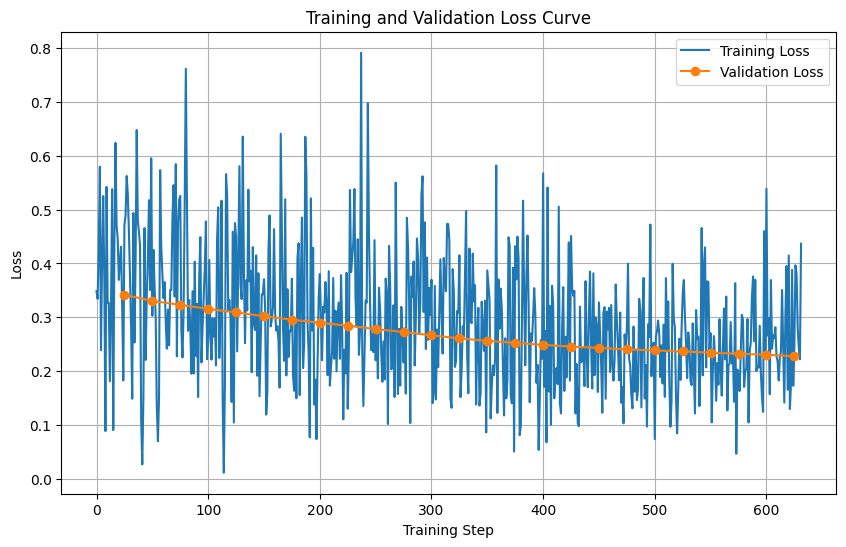

Fial loss: 0.2275, model size: 433M


In [7]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
def evaluate_val_loss(model, val_loader, device):
    model.eval()
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for batch in val_loader:
            labels = batch['labels'].to(device)
            model_inputs = {k: v.to(device) for k, v in batch.items()
                            if k in {"input_ids", "attention_mask", "token_type_ids"}}

            pred = model(**model_inputs)
            logits = pred.logits
            loss = F.cross_entropy(logits, labels)

            total_loss += loss.item() * labels.size(0)
            count += labels.size(0)

    mean_loss = total_loss / count
    return mean_loss

mean_val_loss = evaluate_val_loss(model, val_quick, device)
print(f"start loss: {mean_val_loss:.4f}")

def train_model(model, train_loader, val_loader, device, epochs, lr_op=None):
    model.to(device)
    if not lr_op:
      opt = torch.optim.AdamW(model.parameters(), lr=1e-6)
    else:
      opt = torch.optim.AdamW(model.parameters(), lr=lr_op)
    scaler = torch.cuda.amp.GradScaler()

    train_losses = []
    val_losses = []
    steps = []

    global_step = 0
    for epoch in range(epochs):
        model.train()
        for i, batch in enumerate(train_loader):
            labels = batch['labels'].to(device)
            model_inputs = {k: v.to(device) for k, v in batch.items()
                            if k in {"input_ids", "attention_mask", "token_type_ids"}}

            with torch.cuda.amp.autocast(dtype=torch.float16):
                pred = model(**model_inputs)
                logits = pred.logits
                loss = F.cross_entropy(logits, labels)

            opt.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_losses.append(loss.item())
            global_step += 1

            if global_step % 25 == 0:
                val_loss = evaluate_val_loss(model, val_loader, device)
                val_losses.append(val_loss)
                steps.append(global_step)
                print(f"Epoch {epoch+1}, Step {i+1}/{len(train_loader)}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

    # Plot training and validation loss
    plt.figure(figsize=(10,6))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(steps, val_losses, label="Validation Loss", marker='o')
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

train_model(model, train_loader, val_quick, device, 1)

mean_val_loss = evaluate_val_loss(model, val_quick, device)
print(f"Fial loss: {mean_val_loss:.4f}, model size: 433M")

__Your task__ is to measure the validation accuracy of your model.
Doing so naively may take several hours. Please make sure you use the following optimizations:

- run the model on GPU with no_grad
- using batch size larger than 1
- use optimize data loader with num_workers > 1
- (optional) use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [8]:
# final loss on valdation data is 0.22 while base model performed: 0.37
# as I see there are fluctuations in the train loss I suppose more epoch needed
# but val loss declinessteadily (that is good):
# as I undertand accuracy is roughtly correct/total?
import time

def evaluate_val_accuracy(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0

    start_time = time.time()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            labels = batch['labels'].to(device)
            model_inputs = {k: v.to(device) for k, v in batch.items()
                            if k in {"input_ids", "attention_mask", "token_type_ids"}}
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                pred = model(**model_inputs)
                logits = pred.logits

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if i % 100 == 0:
                print(f"progress: {i}/{len(val_loader)}")

    end_time = time.time()
    elapsed_time = end_time - start_time
    speed_per_sample = elapsed_time / total
    accuracy = correct / total
    print(accuracy, speed_per_sample)
    return accuracy, speed_per_sample

accuracy, speed_per_sample = evaluate_val_accuracy(model, val_loader, device)
print("so accurasy is: ", accuracy, "speed per sample: ", speed_per_sample)

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.9217660153351471 0.0015936882402116698
so accurasy is:  0.9217660153351471 speed per sample:  0.0015936882402116698


In [9]:
# I do not know what to expect as I tuned the model,
# probably it should be more than 0.91 limit (for not trained)

# I will initialize another model and test it:
model_untrained = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)
model_untrained.to(device)
accuracy,  speed_per_sample = evaluate_val_accuracy(model_untrained, val_loader, device)
print("so accurasy is: ", accuracy, "speed per sample: (same)",  speed_per_sample)

assert 0.9 < accuracy < 0.91

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.9084095968340341 0.0015990851687936833
so accurasy is:  0.9084095968340341 speed per sample: (same) 0.0015990851687936833


### Task 2: train the model (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

In [10]:
# I will stick with option A, as even on simple bert model reached accuracy of ~0.99
# I will tune params like epoch, and lr and I think that will be enough.

model_1 = transformers.AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=2
).to(device)
tokenizer_1 = transformers.AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

model_2 = transformers.AutoModelForSequenceClassification.from_pretrained(
    "albert/albert-base-v2",
    num_labels=2
).to(device)
tokenizer_2 = transformers.AutoTokenizer.from_pretrained("albert/albert-base-v2")

model_3 = transformers.AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=2
).to(device)
tokenizer_3 =transformers.AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert/albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predic

In [11]:
# test them without the training:
# in avg_time_per_sample only the forward pass cosidered
models=[model_1, model_2, model_3]
tokenizers = [tokenizer_1,tokenizer_2,tokenizer_3]
model_names = ["roberta-base", "albert-base-v2", "deberta-v3-base"]
model_sizes = ["499M", "47M", "371M"]

for num in range(3):
  tokenizer = tokenizers[num]
  model = models[num]

  MAX_LENGTH = 128
  def preprocess_function(examples):
      result = tokenizer(
          examples['text1'], examples['text2'],
          padding='max_length', max_length=MAX_LENGTH, truncation=True
      )
      result['label'] = examples['label']
      return result

  qqp_preprocessed = qqp['validation'].map(preprocess_function, batched=True)

  val_set = qqp_preprocessed
  val_loader = torch.utils.data.DataLoader(
      val_set, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
  )


  accuracy, speed_per_sample = evaluate_val_accuracy(model, val_loader, device)
  print(f"model name: {model_names[num]}:")
  print(f"model size: {model_sizes[num]}:")
  print(f"accuracy: {accuracy}:")
  print(f"avg time: {speed_per_sample}:")



progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.36816720257234725 0.001481787137633764
model name: roberta-base:
model size: 499M:
accuracy: 0.36816720257234725:
avg time: 0.001481787137633764:
progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.4863220380905268 0.0028273190126364813
model name: albert-base-v2:
model size: 47M:
accuracy: 0.4863220380905268:
avg time: 0.0028273190126364813:
progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.36816720257234725 0.002767321098095528
model name: deberta-v3-base:
model size: 371M:
accuracy: 0.36816720257234725:
avg time: 0.002767321098095528:


**Results:**
model: `roberta-base`
**size: 499Mb**
acc: 0.36
**avg time: 0.001**

model: `albert-base-v2`
size: 47Mb
**acc: 0.38**
avg time: 0.002

model: `deberta-v3-base`
size: 371Mb
acc: 0.36
avg time: 0.002

**The best model is `albert-base-v2`
it is smaller in size and performs better: 0.38**

### Task 3: try the full pipeline (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

In [12]:
# first I will tune the albert-base-v2:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = tokenizer_2(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

val_set = qqp_preprocessed['train'].select(range(10000))
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=32, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=8
)

val_quick_d = qqp_preprocessed['validation'].select(range(1000))
val_quick = torch.utils.data.DataLoader(
    val_quick_d, batch_size=32, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=8
)

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


/tmp/ipython-input-1086130963.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1086130963.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


Epoch 1, Step 25/313, Train Loss: 0.6688, Val Loss: 0.6642
Epoch 1, Step 50/313, Train Loss: 0.6514, Val Loss: 0.6385
Epoch 1, Step 75/313, Train Loss: 0.6320, Val Loss: 0.6241
Epoch 1, Step 100/313, Train Loss: 0.6471, Val Loss: 0.6077
Epoch 1, Step 125/313, Train Loss: 0.6352, Val Loss: 0.5804
Epoch 1, Step 150/313, Train Loss: 0.5807, Val Loss: 0.5621
Epoch 1, Step 175/313, Train Loss: 0.5915, Val Loss: 0.5405
Epoch 1, Step 200/313, Train Loss: 0.5005, Val Loss: 0.5210
Epoch 1, Step 225/313, Train Loss: 0.5252, Val Loss: 0.5115
Epoch 1, Step 250/313, Train Loss: 0.5400, Val Loss: 0.4856
Epoch 1, Step 275/313, Train Loss: 0.5597, Val Loss: 0.4746
Epoch 1, Step 300/313, Train Loss: 0.3939, Val Loss: 0.4862


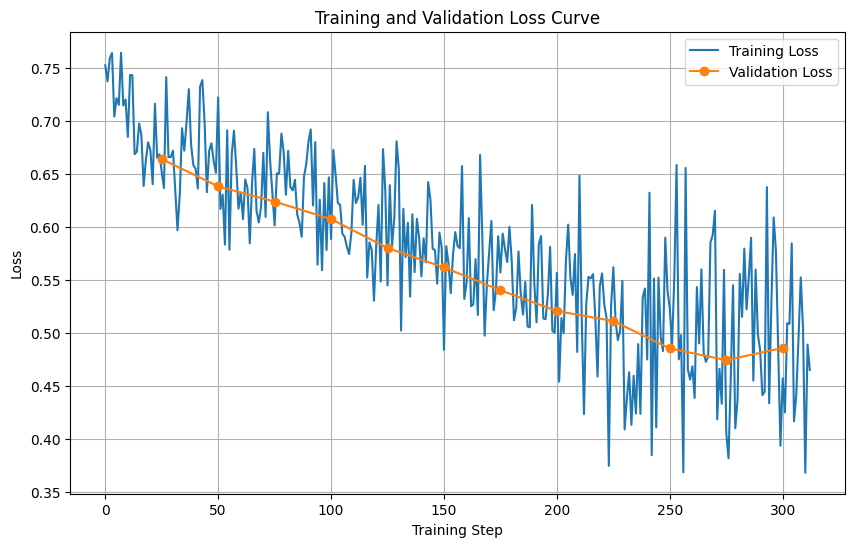

training done!
progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.7839970319069998 0.0028227874025566107
after training results: acc:0.7839970319069998 and avg_speed:0.0028227874025566107


In [13]:
# this is not val_loader vbrlow I forgot to swich names above you can see it is ['train']
train_model(model_2, val_loader, val_quick, device, 1)
print("training done!")

val_qfull = qqp_preprocessed['validation']
val_full = torch.utils.data.DataLoader(
    val_qfull, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=8
)
accuracy, speed_per_sample = evaluate_val_accuracy(model_2, val_full, device)
print(f"after training results: acc:{accuracy} and avg_speed:{speed_per_sample}")
# val accuracy was 0.38 now it is 0.42

In [14]:
MAX_LENGTH = 128

def classify(model, tokenizer, text1, text2, device='cuda'):
    model.eval()
    inputs = tokenizer(
        text1, text2,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1).squeeze(0)

        predicted_class = torch.argmax(probs).item()

    return predicted_class, probs.tolist()

pred_class, pred_probs = classify(model_2, tokenizer_2,
                                  "how to cook?", "delicious meal is easy to make!",
                                  device=device)
print("Predicted class:", pred_class)
print("Class probabilities:", pred_probs)

Predicted class: 0
Class probabilities: [0.6388199329376221, 0.3611800968647003]


__Bonus:__ for bonus points, try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.